In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import os
import pandas as pd

In [2]:
years = [2008, 2009, 2010, 2011, 2012]

output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
for year in years:
    print("Processing HRDPS data for",year)
    hrdps_files = sorted(glob.glob(f"/results/forcing/atmospheric/GEM2.5/gemlam/"f"gemlam_y{year}m??d??.nc"))
    
    combined = []
    
    for file in hrdps_files:
        with xr.open_dataset(file) as ds:
            pressure_data = ds["atmpres"]
            pressure_data = pressure_data.sortby("time_counter")
            time_index = pressure_data.get_index("time_counter")
            if time_index.has_duplicates:
                unique_mask = ~time_index.duplicated()
                pressure_data = pressure_data.isel(time_counter=unique_mask)
            pressure_3h = (pressure_data.resample(time_counter="3h",label="left",closed="left",origin="start_day").mean().load())
            combined.append(pressure_3h)
    
    ds_hrdps_year = xr.concat(combined, dim="time_counter")
    ds_hrdps_year = ds_hrdps_year.sortby("time_counter")
    time_index = ds_hrdps_year.get_index("time_counter")
    if time_index.has_duplicates:
        unique_mask = ~time_index.duplicated()
        ds_hrdps_year = ds_hrdps_year.isel(time_counter=unique_mask)
    
    with xr.open_dataset(hrdps_files[0]) as ds0:
        lat_hr = ds0["nav_lat"].load()
        lon_hr = ds0["nav_lon"].load()

    ds_hrdps_year = (ds_hrdps_year.to_dataset(name="atmpres").assign_coords(nav_lat=lat_hr,nav_lon=lon_hr))
    output_file = f"{output_dir}/HRDPS_{year}_atmpres_3h_with_latlon.nc"
    ds_hrdps_year.to_netcdf(output_file)
    
    print("Saved:", output_file)
    print(
        "Time range:",
        ds_hrdps_year.time_counter.values[0],
        "to",
        ds_hrdps_year.time_counter.values[-1]
    )

In [3]:
hrdps_processed_files = []
for year in years:
    file = f"{output_dir}/HRDPS_{year}_atmpres_3h_with_latlon.nc"
    hrdps_processed_files.append(file)
ds_hrdps = xr.open_mfdataset(hrdps_processed_files,combine="by_coords")
ds_hrdps = ds_hrdps.sortby("time_counter")
print(ds_hrdps)

/tmp/ipykernel_2485533/2742424722.py:5: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_hrdps = xr.open_mfdataset(hrdps_processed_files,combine="by_coords")


<xarray.Dataset> Size: 12GB
Dimensions:       (time_counter: 14592, y: 266, x: 256)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 117kB 2008-01-01 ... 2012-12-...
    nav_lat       (time_counter, y, x) float32 4GB 45.61 45.62 ... 52.37 52.37
    nav_lon       (time_counter, y, x) float32 4GB 232.7 232.7 ... 239.6 239.7
Dimensions without coordinates: y, x
Data variables:
    atmpres       (time_counter, y, x) float32 4GB dask.array<chunksize=(2912, 266, 256), meta=np.ndarray>


In [4]:
print("First timestamp:", ds_hrdps.time_counter.values[0])
print("Last timestamp: ", ds_hrdps.time_counter.values[-1])

First timestamp: 2008-01-01T00:00:00.000000000
Last timestamp:  2012-12-31T21:00:00.000000000


In [5]:
# Training: 2009, 2010, and 2011
ds_hrdps_train = ds_hrdps.sel(time_counter=slice("2009-01-01", "2011-12-31"))
# Validation: 2008
ds_hrdps_val = ds_hrdps.sel(time_counter=slice("2008-01-01", "2008-12-31"))
# Testing: 2012
ds_hrdps_test = ds_hrdps.sel(time_counter=slice("2012-01-01", "2012-12-31"))
print("HRDPS Training:")
print(ds_hrdps_train.time_counter.values[0],"to",ds_hrdps_train.time_counter.values[-1])
print("HRDPS Validation:")
print(ds_hrdps_val.time_counter.values[0],"to",ds_hrdps_val.time_counter.values[-1])
print("HRDPS Testing:")
print(ds_hrdps_test.time_counter.values[0],"to",ds_hrdps_test.time_counter.values[-1])

HRDPS Training:
2009-01-01T00:00:00.000000000 to 2011-12-31T21:00:00.000000000
HRDPS Validation:
2008-01-01T00:00:00.000000000 to 2008-12-31T21:00:00.000000000
HRDPS Testing:
2012-01-01T00:00:00.000000000 to 2012-12-31T21:00:00.000000000


In [6]:
canrcm_files = sorted(glob.glob("/results/forcing/CanRCM5/*.nc"))

In [7]:
canrcm_years = [2008, 2009, 2010, 2011, 2012]
canrcm_tas_files = []
for year in canrcm_years:
    matches = sorted(glob.glob(f"/results/forcing/CanRCM5/"f"*_{year}01_{year}12_3h_psl.nc"))
    canrcm_tas_files.append(matches[0])

print("CanRCM pressure files:")
for file in canrcm_tas_files:
    print(file)

CanRCM pressure files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_psl.nc


In [8]:
from datetime import timedelta
ds_canrcm = xr.open_mfdataset(canrcm_tas_files,combine="by_coords")
ds_canrcm = ds_canrcm.sortby("time")
ds_canrcm = ds_canrcm.assign_coords(time=ds_canrcm.time.values - timedelta(hours=3))
print(ds_canrcm)

<xarray.Dataset> Size: 7GB
Dimensions:       (time: 14600, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:0...
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
    lat           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 234kB dask.array<chunksize=(2920, 2), meta=np.ndarray>
    rotated_pole  (time) |S1 15kB b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    psl           (time, rlat, rlon) float32 7GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
Attributes: (12/19)
    CDI:                            Climate Data Interface version 2.0.3 (htt...
    Conventions:                    

/tmp/ipykernel_2485533/3930337657.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm = xr.open_mfdataset(canrcm_tas_files,combine="by_coords")


In [9]:
print("First timestamp:")
print(ds_canrcm.time.values[0])
print("Last timestamp:")
print(ds_canrcm.time.values[-1])

First timestamp:
2008-01-01 00:00:00
Last timestamp:
2012-12-31 21:00:00


In [10]:
lat_hr = ds_hrdps["nav_lat"]
lon_hr = ds_hrdps["nav_lon"]
lon_hr_normalized = ((lon_hr + 180) % 360) - 180
lat_min = float(lat_hr.min())
lat_max = float(lat_hr.max())
lon_min = float(lon_hr_normalized.min())
lon_max = float(lon_hr_normalized.max())
print("HRDPS latitude range:")
print(lat_min, "to", lat_max)
print("HRDPS longitude range:")
print(lon_min, "to", lon_max)

HRDPS latitude range:
45.52116012573242 to 52.4603157043457
HRDPS longitude range:
-129.47222900390625 to -119.20327758789062


In [11]:
lat_lr = ds_canrcm["lat"]
lon_lr = ds_canrcm["lon"]
lon_lr_normalized = ((lon_lr + 180) % 360) - 180
mask_lr = ((lat_lr >= lat_min) &(lat_lr <= lat_max) &(lon_lr_normalized >= lon_min) &(lon_lr_normalized <= lon_max))
i_idx, j_idx = np.where(mask_lr.values)
i_min = i_idx.min()
i_max = i_idx.max()
j_min = j_idx.min()
j_max = j_idx.max()
print("CanRCM grid indices:")
print("rlat:", i_min, "to", i_max)
print("rlon:", j_min, "to", j_max)

CanRCM grid indices:
rlat: 161 to 200
rlon: 79 to 117


In [12]:
ds_canrcm_cut = (ds_canrcm[["psl"]].isel(rlat=slice(i_min, i_max + 1),rlon=slice(j_min, j_max + 1)))
print(ds_canrcm_cut)

<xarray.Dataset> Size: 91MB
Dimensions:  (time: 14600, rlat: 40, rlon: 39)
Coordinates:
  * time     (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:00:00
  * rlat     (rlat) float64 320B 0.31 0.53 0.75 0.97 ... 8.23 8.45 8.67 8.89
  * rlon     (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.97 -13.75 -13.53
    lon      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
    lat      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
Data variables:
    psl      (time, rlat, rlon) float32 91MB dask.array<chunksize=(2920, 40, 39), meta=np.ndarray>
Attributes: (12/19)
    CDI:                            Climate Data Interface version 2.0.3 (htt...
    Conventions:                    CF-1.4
    institution:                    CCCma (Canadian Centre for Climate Modell...
    title:                          CanRCM4 model output prepared for CORDEX ...
    institute_id:                   CCCma
    driving_experiment:             , , r1

In [13]:
# Training: 2009, 2010, and 2011
ds_canrcm_train = ds_canrcm_cut.sel(time=slice("2009-01-01", "2011-12-31"))
# Validation: 2008
ds_canrcm_val = ds_canrcm_cut.sel(time=slice("2008-01-01", "2008-12-31"))
# Testing: 2012
ds_canrcm_test = ds_canrcm_cut.sel(time=slice("2012-01-01", "2012-12-31"))
print("CanRCM Training:")
print(ds_canrcm_train.time.values[0], "to", ds_canrcm_train.time.values[-1])
print("CanRCM Validation:")
print(ds_canrcm_val.time.values[0], "to", ds_canrcm_val.time.values[-1])
print("CanRCM Testing:")
print(ds_canrcm_test.time.values[0], "to", ds_canrcm_test.time.values[-1])

CanRCM Training:
2009-01-01 00:00:00 to 2011-12-31 21:00:00
CanRCM Validation:
2008-01-01 00:00:00 to 2008-12-31 21:00:00
CanRCM Testing:
2012-01-01 00:00:00 to 2012-12-31 21:00:00


In [14]:
def time_to_string(value):
    if isinstance(value, np.datetime64):
        return np.datetime_as_string(value,unit="s").replace("T", " ")
    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")
    raise TypeError(f"Unsupported time type: {type(value)}")

def align_time_pair(ds_canrcm_split, ds_hrdps_split):
    canrcm_times = []
    for t in ds_canrcm_split.time.values:
        canrcm_times.append(time_to_string(t))
    canrcm_times = np.array(canrcm_times)
    
    hrdps_times = []
    for t in ds_hrdps_split.time_counter.values:
        hrdps_times.append(time_to_string(t))
    hrdps_times = np.array(hrdps_times)
    
    common_times, canrcm_idx, hrdps_idx = np.intersect1d(canrcm_times,hrdps_times,return_indices=True)
    ds_canrcm_aligned = ds_canrcm_split.isel(time=canrcm_idx)
    ds_hrdps_aligned = ds_hrdps_split.isel(time_counter=hrdps_idx)
    
    return ds_canrcm_aligned, ds_hrdps_aligned

In [15]:
ds_canrcm_train, ds_hrdps_train = align_time_pair(ds_canrcm_train,ds_hrdps_train)
ds_canrcm_val, ds_hrdps_val = align_time_pair(ds_canrcm_val,ds_hrdps_val)
ds_canrcm_test, ds_hrdps_test = align_time_pair(ds_canrcm_test,ds_hrdps_test)
print("Training:")
print("CanRCM:", len(ds_canrcm_train.time))
print("HRDPS: ", len(ds_hrdps_train.time_counter))
print("Validation:")
print("CanRCM:", len(ds_canrcm_val.time))
print("HRDPS: ", len(ds_hrdps_val.time_counter))
print("Testing:")
print("CanRCM:", len(ds_canrcm_test.time))
print("HRDPS: ", len(ds_hrdps_test.time_counter))

Training:
CanRCM: 8760
HRDPS:  8760
Validation:
CanRCM: 2904
HRDPS:  2904
Testing:
CanRCM: 2912
HRDPS:  2912


In [19]:
mesh_mask_file = "/ocean/dtaneja/MOAD/analysis-dishika/grid/mesh_mask202108.nc"
weights_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_pre22sep11.nc"
ds_mask = xr.open_dataset(mesh_mask_file)
ds_weights = xr.open_dataset(weights_file)
print(ds_weights)
print(ds_mask)

<xarray.Dataset> Size: 24MB
Dimensions:  (lat: 266, lon: 256, y: 898, x: 398)
Dimensions without coordinates: lat, lon, y, x
Data variables:
    nav_lat  (lat, lon) float64 545kB ...
    nav_lon  (lat, lon) float64 545kB ...
    src01    (y, x) int64 3MB ...
    wgt01    (y, x) float64 3MB ...
    src02    (y, x) int64 3MB ...
    wgt02    (y, x) float64 3MB ...
    src03    (y, x) int64 3MB ...
    wgt03    (y, x) float64 3MB ...
    src04    (y, x) int64 3MB ...
    wgt04    (y, x) float64 3MB ...
Attributes:
    Conventions:  CF-1.6
    title:        SalishSeaCast NEMO GEMLAM 2.5km Experimental pre-22-Sep-201...
    institution:  Dept of Earth, Ocean & Atmospheric Sciences, University of ...
    source:       NEMO_EastCoast/NEMO_Preparation/4_weights_ATMOS/get_weight_...
    references:   https://salishsea-meopar-docs.readthedocs.io/en/latest/code...
    history:      [2022-03-21 12:04:51] Converted to netCDF4 zlib=True datase...
    comment:      
<xarray.Dataset> Size: 788MB
Dimen

In [20]:
tmask2d = ds_mask["tmask"].isel(t=0, z=0)
water_mask = tmask2d.values.astype(bool)

ny, nx = water_mask.shape

print("SalishSeaCast shape:", ny, nx)
print("Number of water cells:", water_mask.sum())

SalishSeaCast shape: 898 398
Number of water cells: 81383


In [21]:
def interpolate_with_nemo_weights(da_hrdps, ds_weights):
    """
    Interpolate HRDPS field to SalishSeaCast grid using NEMO-style weights.

    Input:
        da_hrdps dims should be:
        time_counter, y, x
        or time_counter, lat, lon

    Output:
        DataArray on SalishSeaCast grid:
        time_counter, y, x
    """

    da_hrdps = da_hrdps.squeeze(drop=True)

    time_dim = da_hrdps.dims[0]

    n_time = da_hrdps.sizes[time_dim]

    source_values = da_hrdps.values.reshape(n_time, -1).astype(np.float32)

    n_source_cells = source_values.shape[1]

    out = np.zeros((n_time, ds_weights.sizes["y"], ds_weights.sizes["x"]), dtype=np.float32)

    for n in range(1, 5):
        src_name = f"src{n:02d}"
        wgt_name = f"wgt{n:02d}"

        src = ds_weights[src_name].values.astype(np.int64)
        wgt = ds_weights[wgt_name].values.astype(np.float32)

        # Most NEMO weights are 1-based, so convert to 0-based Python indexing
        if src.min() >= 1:
            src = src - 1

        if src.max() >= n_source_cells:
            raise ValueError(
                f"{src_name} has source index {src.max()}, but source field only has "
                f"{n_source_cells} cells. Check source grid shape/order."
            )

        interpolated_piece = source_values[:, src] * wgt[None, :, :]

        out += interpolated_piece

    da_out = xr.DataArray(
        out,
        dims=("time_counter", "y", "x"),
        coords={
            "time_counter": da_hrdps[time_dim].values,
            "nav_lat": (("y", "x"), ds_mask["nav_lat"].values),
            "nav_lon": (("y", "x"), ds_mask["nav_lon"].values),
        },
        name="atmpres_ssc"
    )

    return da_out

In [22]:
hrdps_train_ssc = interpolate_with_nemo_weights(
    ds_hrdps_train["atmpres"],
    ds_weights
)

hrdps_val_ssc = interpolate_with_nemo_weights(
    ds_hrdps_val["atmpres"],
    ds_weights
)

hrdps_test_ssc = interpolate_with_nemo_weights(
    ds_hrdps_test["atmpres"],
    ds_weights
)

print(hrdps_train_ssc)
print(hrdps_val_ssc)
print(hrdps_test_ssc)

<xarray.DataArray 'atmpres_ssc' (time_counter: 8684, y: 898, x: 398)> Size: 12GB
array([[[102068.97 , 102068.82 , 102068.664, ..., 101944.77 ,
         101943.38 , 101941.99 ],
        [102068.266, 102068.1  , 102067.945, ..., 101941.81 ,
         101940.42 , 101939.016],
        [102067.516, 102067.35 , 102067.14 , ..., 101938.86 ,
         101937.42 , 101935.95 ],
        ...,
        [101340.414, 101337.73 , 101334.414, ..., 101210.7  ,
         101211.44 , 101212.17 ],
        [101339.04 , 101336.58 , 101333.195, ..., 101208.05 ,
         101208.78 , 101209.47 ],
        [101337.734, 101335.195, 101332.02 , ..., 101205.43 ,
         101206.164, 101206.875]],

       [[101943.97 , 101944.1  , 101944.336, ..., 101919.38 ,
         101918.6  , 101917.836],
        [101943.24 , 101943.32 , 101943.53 , ..., 101916.766,
         101916.02 , 101915.29 ],
        [101942.47 , 101942.51 , 101942.73 , ..., 101914.14 ,
         101913.38 , 101912.61 ],
...
        [102849.02 , 102849.55 , 102

In [23]:
hrdps_train_ssc = hrdps_train_ssc.where(tmask2d == 1)
hrdps_val_ssc = hrdps_val_ssc.where(tmask2d == 1)
hrdps_test_ssc = hrdps_test_ssc.where(tmask2d == 1)

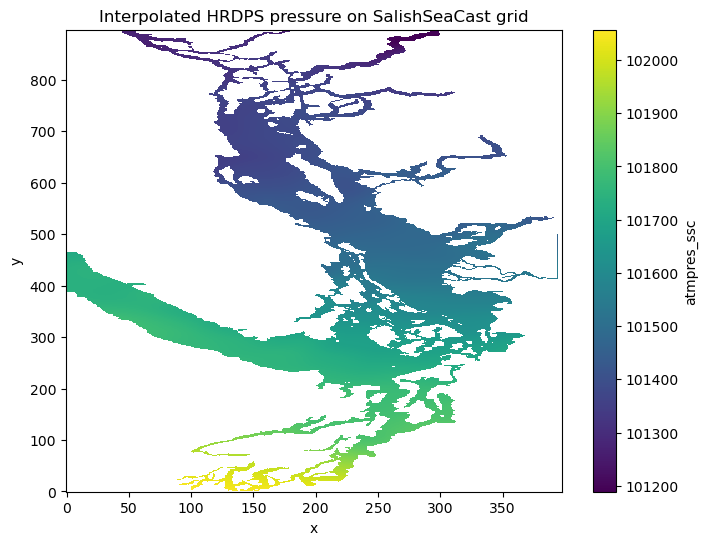

In [24]:
plt.figure(figsize=(8, 6))
hrdps_train_ssc.isel(time_counter=0).plot()
plt.title("Interpolated HRDPS pressure on SalishSeaCast grid")
plt.show()

In [25]:
def make_target_matrix_from_ssc(da_ssc, valid_cells=None):
    """
    Converts interpolated HRDPS pressure on SalishSeaCast grid into matrix form.

    Rows = timestamps
    Columns = valid SalishSeaCast water cells
    """

    X_raw = da_ssc.values.reshape(da_ssc.sizes["time_counter"], -1).astype(np.float32)

    water_flat = water_mask.reshape(-1)

    if valid_cells is None:
        valid_cells = water_flat & np.isfinite(X_raw).all(axis=0)

    X = X_raw[:, valid_cells]

    keep_time = np.isfinite(X).all(axis=1)

    X = X[keep_time]

    return X, keep_time, valid_cells

In [26]:
X_hrdps_train, keep_train_time, valid_ssc_cells = make_target_matrix_from_ssc(
    hrdps_train_ssc
)

X_hrdps_val, keep_val_time, _ = make_target_matrix_from_ssc(
    hrdps_val_ssc,
    valid_cells=valid_ssc_cells
)

X_hrdps_test, keep_test_time, _ = make_target_matrix_from_ssc(
    hrdps_test_ssc,
    valid_cells=valid_ssc_cells
)

print("HRDPS train target matrix:", X_hrdps_train.shape)
print("HRDPS val target matrix:  ", X_hrdps_val.shape)
print("HRDPS test target matrix: ", X_hrdps_test.shape)

HRDPS train target matrix: (8684, 81383)
HRDPS val target matrix:   (2842, 81383)
HRDPS test target matrix:  (2912, 81383)


In [27]:
ds_canrcm_train_final = ds_canrcm_train.isel(time=keep_train_time)
ds_canrcm_val_final = ds_canrcm_val.isel(time=keep_val_time)
ds_canrcm_test_final = ds_canrcm_test.isel(time=keep_test_time)

In [28]:
X_canrcm_train = ds_canrcm_train_final["psl"].squeeze(drop=True).values.reshape(
    len(ds_canrcm_train_final.time), -1
).astype(np.float32)

X_canrcm_val = ds_canrcm_val_final["psl"].squeeze(drop=True).values.reshape(
    len(ds_canrcm_val_final.time), -1
).astype(np.float32)

X_canrcm_test = ds_canrcm_test_final["psl"].squeeze(drop=True).values.reshape(
    len(ds_canrcm_test_final.time), -1
).astype(np.float32)

print("CanRCM train input matrix:", X_canrcm_train.shape)
print("CanRCM val input matrix:  ", X_canrcm_val.shape)
print("CanRCM test input matrix: ", X_canrcm_test.shape)

print("HRDPS train target matrix:", X_hrdps_train.shape)
print("HRDPS val target matrix:  ", X_hrdps_val.shape)
print("HRDPS test target matrix: ", X_hrdps_test.shape)

CanRCM train input matrix: (8684, 1560)
CanRCM val input matrix:   (2842, 1560)
CanRCM test input matrix:  (2912, 1560)
HRDPS train target matrix: (8684, 81383)
HRDPS val target matrix:   (2842, 81383)
HRDPS test target matrix:  (2912, 81383)


In [29]:
max_hrdps_pcs_for_search = min(
    300,
    X_hrdps_train.shape[0] - 1,
    X_hrdps_train.shape[1]
)

pca_hrdps = PCA(
    n_components=max_hrdps_pcs_for_search,
    svd_solver="randomized",
    random_state=0
)

hrdps_train_scores_all = pca_hrdps.fit_transform(X_hrdps_train)

hrdps_cumulative_variance = np.cumsum(pca_hrdps.explained_variance_ratio_)

print("Maximum cumulative variance reached:")
print(hrdps_cumulative_variance[-1])

Maximum cumulative variance reached:
0.99999785


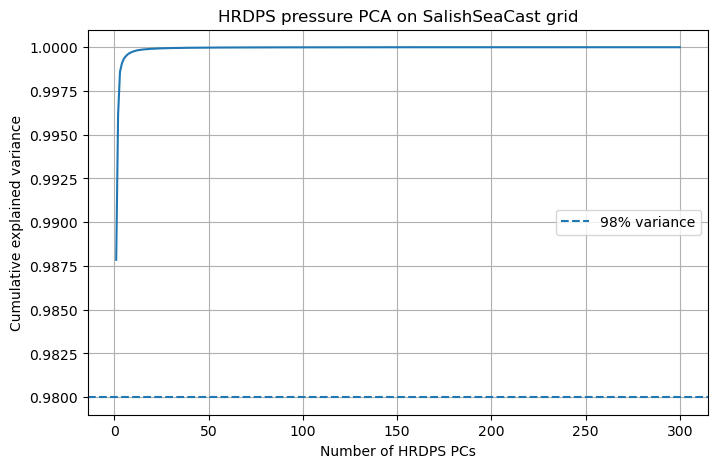

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(
    np.arange(1, len(hrdps_cumulative_variance) + 1),
    hrdps_cumulative_variance
)
plt.axhline(0.98, linestyle="--", label="98% variance")
plt.xlabel("Number of HRDPS PCs")
plt.ylabel("Cumulative explained variance")
plt.title("HRDPS pressure PCA on SalishSeaCast grid")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
if hrdps_cumulative_variance[-1] < 0.98:
    raise ValueError(
        "98% variance was not reached. Increase max_hrdps_pcs_for_search."
    )

n_hrdps_pcs = np.argmax(hrdps_cumulative_variance >= 0.98) + 1

print("Number of HRDPS PCs needed for 98% variance:")
print(n_hrdps_pcs)

Number of HRDPS PCs needed for 98% variance:
1


In [34]:
hrdps_val_scores_all = pca_hrdps.transform(X_hrdps_val)
hrdps_test_scores_all = pca_hrdps.transform(X_hrdps_test)

hrdps_train_scores = hrdps_train_scores_all[:, :n_hrdps_pcs]
hrdps_val_scores = hrdps_val_scores_all[:, :n_hrdps_pcs]
hrdps_test_scores = hrdps_test_scores_all[:, :n_hrdps_pcs]

In [35]:
max_canrcm_pcs_for_search = min(
    100,
    X_canrcm_train.shape[0] - 1,
    X_canrcm_train.shape[1]
)

pca_canrcm = PCA(n_components=max_canrcm_pcs_for_search)

canrcm_train_scores_all = pca_canrcm.fit_transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
canrcm_test_scores_all = pca_canrcm.transform(X_canrcm_test)

canrcm_cumulative_variance = np.cumsum(pca_canrcm.explained_variance_ratio_)

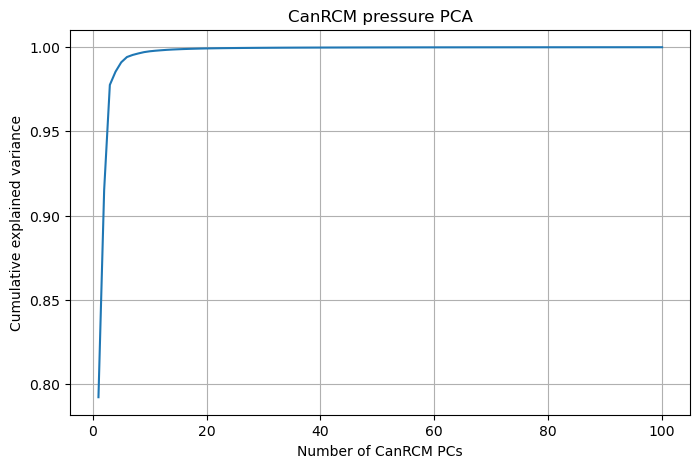

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(
    np.arange(1, len(canrcm_cumulative_variance) + 1),
    canrcm_cumulative_variance
)
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Cumulative explained variance")
plt.title("CanRCM pressure PCA")
plt.grid(True)
plt.show()

In [37]:
results = []

for k in range(1, max_canrcm_pcs_for_search + 1):

    X_train_k = canrcm_train_scores_all[:, :k]
    X_val_k = canrcm_val_scores_all[:, :k]

    model_k = LinearRegression()
    model_k.fit(X_train_k, hrdps_train_scores)

    hrdps_val_scores_pred = model_k.predict(X_val_k)

    val_r2_uniform = r2_score(
        hrdps_val_scores,
        hrdps_val_scores_pred,
        multioutput="uniform_average"
    )

    val_r2_variance_weighted = r2_score(
        hrdps_val_scores,
        hrdps_val_scores_pred,
        multioutput="variance_weighted"
    )

    results.append(
        {
            "n_canrcm_pcs": k,
            "val_r2_uniform": val_r2_uniform,
            "val_r2_variance_weighted": val_r2_variance_weighted,
        }
    )

results_df = pd.DataFrame(results)

results_df.head()

,n_canrcm_pcs,val_r2_uniform,val_r2_variance_weighted
0,1,0.904107,0.904107
1,2,0.910632,0.910632
2,3,0.938108,0.938108
3,4,0.940295,0.940295
4,5,0.965054,0.965054


In [38]:
best_row = results_df.loc[results_df["val_r2_variance_weighted"].idxmax()]

n_canrcm_pcs = int(best_row["n_canrcm_pcs"])

print("Best number of CanRCM PCs:")
print(n_canrcm_pcs)

print("Best validation result:")
print(best_row)

Best number of CanRCM PCs:
80
Best validation result:
n_canrcm_pcs                80.000000
val_r2_uniform               0.969272
val_r2_variance_weighted     0.969272
Name: 79, dtype: float64


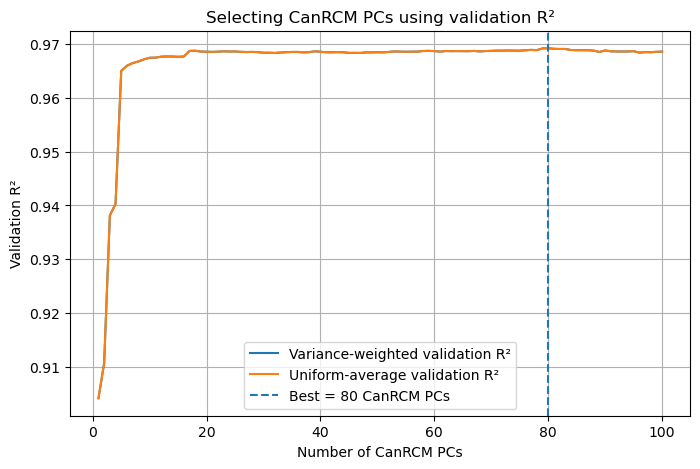

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(
    results_df["n_canrcm_pcs"],
    results_df["val_r2_variance_weighted"],
    label="Variance-weighted validation R²"
)
plt.plot(
    results_df["n_canrcm_pcs"],
    results_df["val_r2_uniform"],
    label="Uniform-average validation R²"
)
plt.axvline(
    n_canrcm_pcs,
    linestyle="--",
    label=f"Best = {n_canrcm_pcs} CanRCM PCs"
)
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Validation R²")
plt.title("Selecting CanRCM PCs using validation R²")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
final_model = LinearRegression()

final_model.fit(
    canrcm_train_scores_all[:, :n_canrcm_pcs],
    hrdps_train_scores
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float32](1, 80)","[[ 7.44, -1.76, -4.04,..., 25.3 ,-97.45, 17.89]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float32](1,)",[-8.49]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,80
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,80
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float32](80,)","[2.80e+06,1.10e+06,7.87e+05,...,4.36e+03,4.32e+03,4.24e+03]"


In [41]:
hrdps_test_scores_pred = final_model.predict(
    canrcm_test_scores_all[:, :n_canrcm_pcs]
)

In [42]:
def inverse_from_selected_pcs(selected_scores, pca_object, n_selected_pcs):
    full_scores = np.zeros(
        (selected_scores.shape[0], pca_object.n_components_),
        dtype=np.float32
    )

    full_scores[:, :n_selected_pcs] = selected_scores

    reconstructed = pca_object.inverse_transform(full_scores)

    return reconstructed

In [43]:
X_hrdps_test_pred = inverse_from_selected_pcs(
    hrdps_test_scores_pred,
    pca_hrdps,
    n_hrdps_pcs
)

print("Predicted HRDPS test matrix:")
print(X_hrdps_test_pred.shape)

Predicted HRDPS test matrix:
(2912, 81383)


In [46]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
test_rmse = np.sqrt(
    mean_squared_error(
        X_hrdps_test.ravel(),
        X_hrdps_test_pred.ravel()
    )
)

test_mae = mean_absolute_error(
    X_hrdps_test.ravel(),
    X_hrdps_test_pred.ravel()
)

test_bias = np.mean(X_hrdps_test_pred - X_hrdps_test)

test_r2_grid = r2_score(
    X_hrdps_test.ravel(),
    X_hrdps_test_pred.ravel()
)

test_r2_pc = r2_score(
    hrdps_test_scores,
    hrdps_test_scores_pred,
    multioutput="variance_weighted"
)

print("Final test metrics on SalishSeaCast water grid:")
print("RMSE:", test_rmse)
print("MAE: ", test_mae)
print("Bias:", test_bias)
print("Grid-cell flattened R²:", test_r2_grid)
print("PC-space variance-weighted R²:", test_r2_pc)

Final test metrics on SalishSeaCast water grid:
RMSE: 169.44437001933701
MAE:  129.48146057128906
Bias: -49.302048
Grid-cell flattened R²: 0.9589788913726807
PC-space variance-weighted R²: 0.9702251553535461


In [47]:
time_test = ds_hrdps_test.time_counter.values[keep_test_time]

In [48]:
def vector_to_ssc_da(X_matrix, times, name):
    full = np.full(
        (X_matrix.shape[0], ny * nx),
        np.nan,
        dtype=np.float32
    )

    full[:, valid_ssc_cells] = X_matrix.astype(np.float32)

    data_3d = full.reshape(X_matrix.shape[0], ny, nx)

    da = xr.DataArray(
        data_3d,
        dims=("time_counter", "y", "x"),
        coords={
            "time_counter": times,
            "nav_lat": (("y", "x"), ds_mask["nav_lat"].values),
            "nav_lon": (("y", "x"), ds_mask["nav_lon"].values),
        },
        name=name
    )

    return da

In [49]:
pred_da = vector_to_ssc_da(
    X_hrdps_test_pred,
    time_test,
    "atmpres_pred"
)

actual_da = vector_to_ssc_da(
    X_hrdps_test,
    time_test,
    "atmpres_actual"
)

error_da = pred_da - actual_da
error_da = error_da.rename("atmpres_error")

In [50]:
ds_predictions = xr.Dataset(
    {
        "atmpres_pred": pred_da,
        "atmpres_actual": actual_da,
        "atmpres_error": error_da,
    }
)

output_file = f"{output_dir}/PCA_LR_pressure_predictions_2012_SalishSeaCast_grid.nc"

ds_predictions.to_netcdf(output_file)

print("Saved:")
print(output_file)

Saved:
/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/PCA_LR_pressure_predictions_2012_SalishSeaCast_grid.nc


In [51]:
error_matrix = X_hrdps_test_pred - X_hrdps_test

spatial_rmse_vec = np.sqrt(np.mean(error_matrix ** 2, axis=0))
spatial_bias_vec = np.mean(error_matrix, axis=0)

In [52]:
def vector_to_ssc_map(vector, name):
    full = np.full(ny * nx, np.nan, dtype=np.float32)

    full[valid_ssc_cells] = vector.astype(np.float32)

    data_2d = full.reshape(ny, nx)

    da = xr.DataArray(
        data_2d,
        dims=("y", "x"),
        coords={
            "nav_lat": (("y", "x"), ds_mask["nav_lat"].values),
            "nav_lon": (("y", "x"), ds_mask["nav_lon"].values),
        },
        name=name
    )

    return da

In [53]:
spatial_rmse_da = vector_to_ssc_map(
    spatial_rmse_vec,
    "spatial_rmse"
)

spatial_bias_da = vector_to_ssc_map(
    spatial_bias_vec,
    "spatial_bias"
)

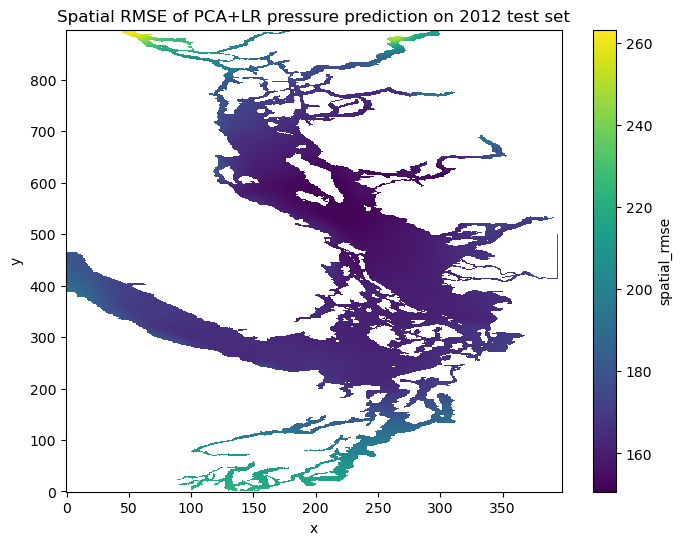

In [54]:
plt.figure(figsize=(8, 6))
spatial_rmse_da.plot()
plt.title("Spatial RMSE of PCA+LR pressure prediction on 2012 test set")
plt.show()

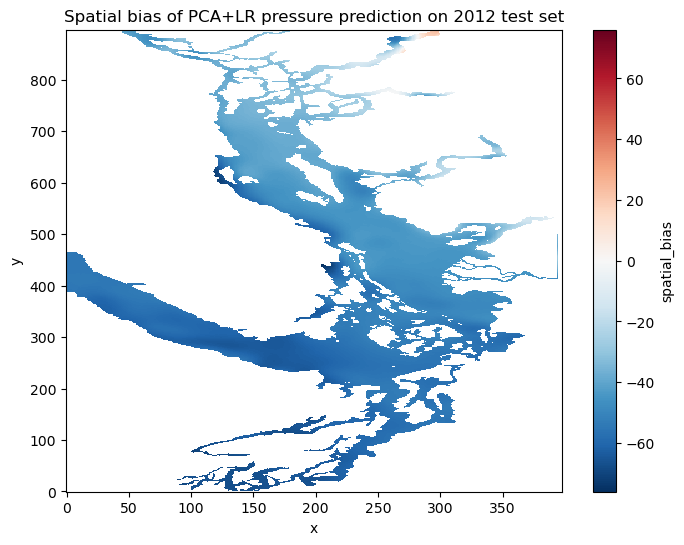

In [55]:
plt.figure(figsize=(8, 6))
spatial_bias_da.plot()
plt.title("Spatial bias of PCA+LR pressure prediction on 2012 test set")
plt.show()

In [56]:
ds_spatial_metrics = xr.Dataset(
    {
        "spatial_rmse": spatial_rmse_da,
        "spatial_bias": spatial_bias_da,
    }
)

spatial_metrics_file = f"{output_dir}/PCA_LR_pressure_spatial_metrics_2012_SalishSeaCast_grid.nc"

ds_spatial_metrics.to_netcdf(spatial_metrics_file)

print("Saved:")
print(spatial_metrics_file)

Saved:
/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/PCA_LR_pressure_spatial_metrics_2012_SalishSeaCast_grid.nc


In [57]:
rmse_3h = np.sqrt(np.mean(error_matrix ** 2, axis=1))
mae_3h = np.mean(np.abs(error_matrix), axis=1)
bias_3h = np.mean(error_matrix, axis=1)

metrics_3h = pd.DataFrame(
    {
        "rmse": rmse_3h,
        "mae": mae_3h,
        "bias": bias_3h,
    },
    index=pd.to_datetime(time_test)
)

daily_metrics = metrics_3h.resample("1D").mean()

daily_metrics.head()

,rmse,mae,bias
2012-01-01,100.764290,79.571945,9.966183
2012-01-02,247.893936,231.184921,179.691879
2012-01-03,274.839020,242.880508,128.975540
2012-01-04,296.793793,250.821243,-187.859497
2012-01-05,208.972549,179.280319,-84.671692


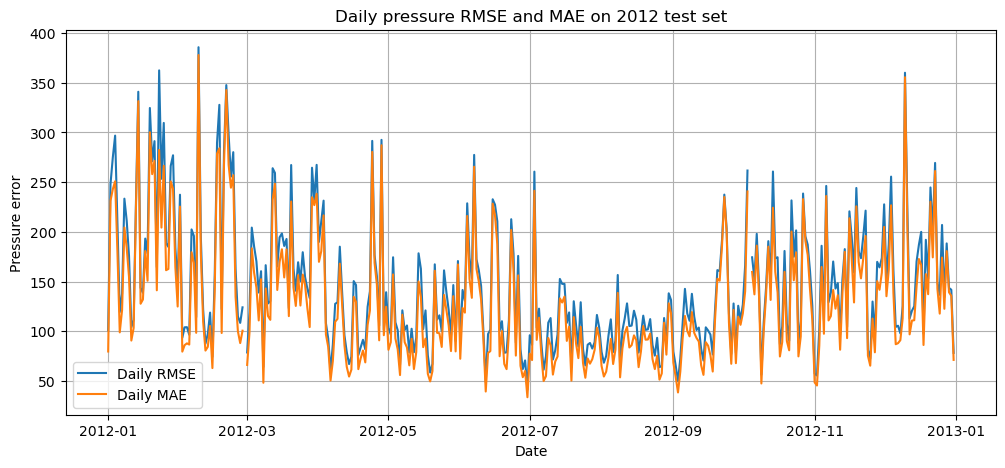

In [58]:
plt.figure(figsize=(12, 5))
plt.plot(daily_metrics.index, daily_metrics["rmse"], label="Daily RMSE")
plt.plot(daily_metrics.index, daily_metrics["mae"], label="Daily MAE")
plt.xlabel("Date")
plt.ylabel("Pressure error")
plt.title("Daily pressure RMSE and MAE on 2012 test set")
plt.legend()
plt.grid(True)
plt.show()

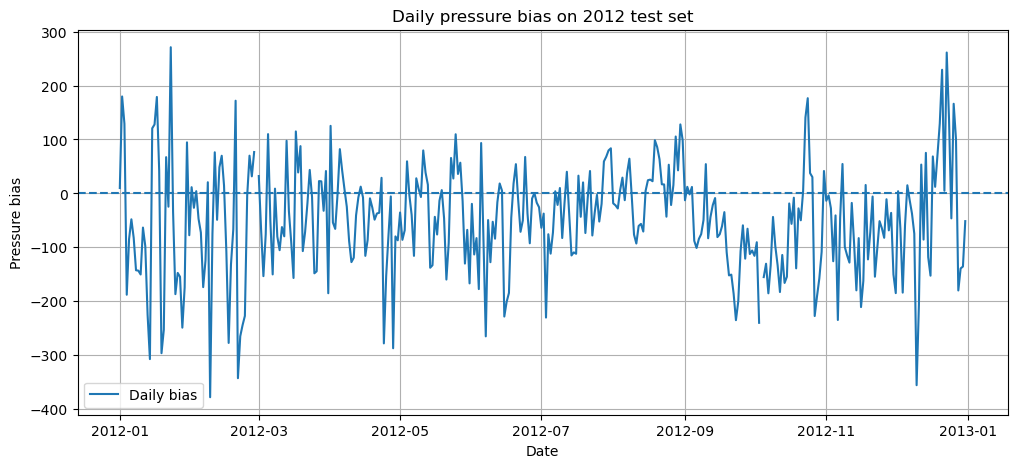

In [59]:
plt.figure(figsize=(12, 5))
plt.plot(daily_metrics.index, daily_metrics["bias"], label="Daily bias")
plt.axhline(0, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Pressure bias")
plt.title("Daily pressure bias on 2012 test set")
plt.legend()
plt.grid(True)
plt.show()

In [60]:
daily_metrics_file = f"{output_dir}/PCA_LR_pressure_daily_metrics_2012.csv"

daily_metrics.to_csv(daily_metrics_file)

print("Saved:")
print(daily_metrics_file)

Saved:
/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/PCA_LR_pressure_daily_metrics_2012.csv


In [61]:
plot_index = 0

actual_map = vector_to_ssc_map(
    X_hrdps_test[plot_index],
    "actual_pressure"
)

pred_map = vector_to_ssc_map(
    X_hrdps_test_pred[plot_index],
    "predicted_pressure"
)

error_map = pred_map - actual_map
error_map = error_map.rename("prediction_error")

plot_time = pd.to_datetime(time_test[plot_index])

print("Plotting timestamp:")
print(plot_time)

Plotting timestamp:
2012-01-01 00:00:00


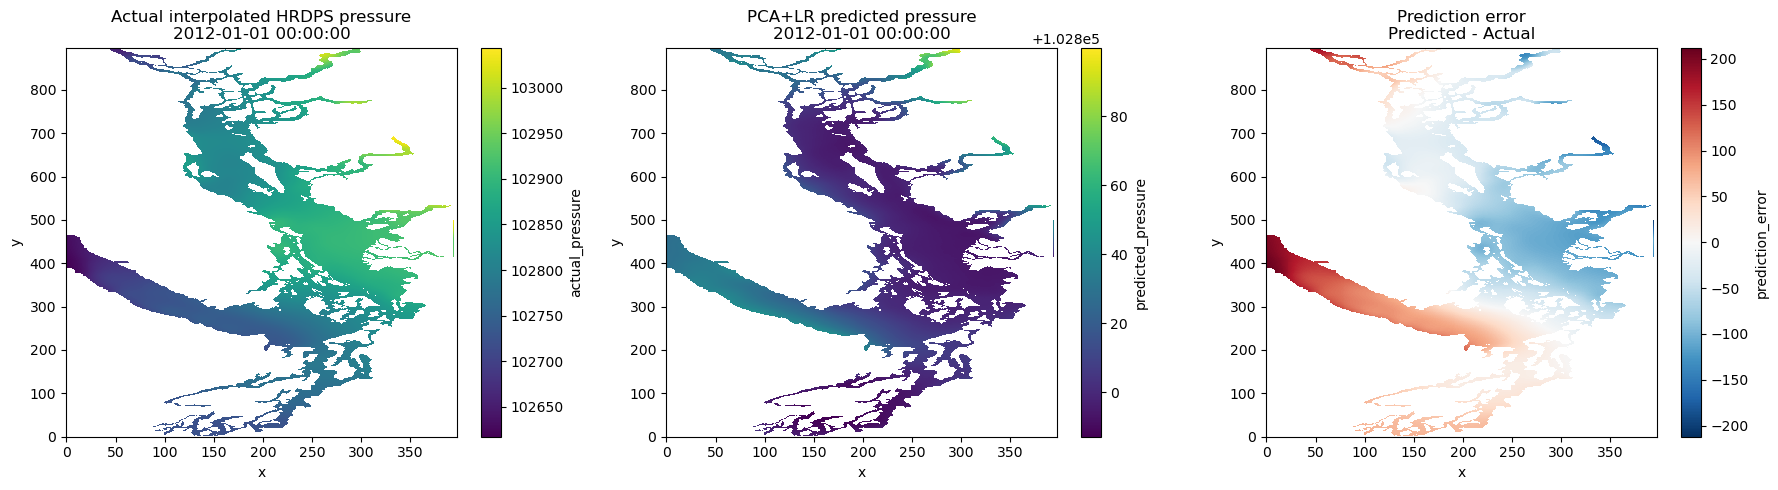

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

actual_map.plot(ax=axes[0])
axes[0].set_title(f"Actual interpolated HRDPS pressure\n{plot_time}")

pred_map.plot(ax=axes[1])
axes[1].set_title(f"PCA+LR predicted pressure\n{plot_time}")

error_map.plot(ax=axes[2])
axes[2].set_title("Prediction error\nPredicted - Actual")

plt.tight_layout()
plt.show()